# HITO 3 – 
## Reconocimiento y Clasificación de Tumores Cerebrales – Desarrollo e Integración de Servicios de IA

## 1. Carga de los datos

En el Hito 2 se realizó la organización del conjunto de datos del que disponemos en 3 carpetas: train, conjunto de entrenamiento; val, conjunto de validación; y test, conjunto de prueba. En este Hito solo será necesario cargar los datos guardados en dichas carpetas.

In [94]:
from pathlib import Path
from tensorflow import keras
import os
import pandas as pd
random_state = 42
batch_size = 32  
image_size = (256,256)
directory = Path(".") / "data"/ "train"  # Directorio donde se ubican los datos
# Genera los datasets de train, validación y test a partir de las imágenes de los directorios
ds_train = keras.utils.image_dataset_from_directory(directory, batch_size = batch_size, image_size = image_size, seed = random_state)
directory = Path(".") / "data" / "val"
ds_validation = keras.utils.image_dataset_from_directory(directory, batch_size = batch_size, image_size = image_size, seed = random_state)
directory = Path(".") / "data" / "test"
ds_test = keras.utils.image_dataset_from_directory(directory, batch_size = batch_size, image_size = image_size, shuffle = False)

Found 1855 files belonging to 4 classes.
Found 617 files belonging to 4 classes.
Found 624 files belonging to 4 classes.


Asimismo, volvemos a definir el ajuste de pesos realizado para solventar el desbalanceo de clases, ya que la clase 'normal' consta de menos instancias.

meningioma_tumor
glioma_tumor
pituitary_tumor
normal
Pesos para cada clase:
------------------------------------
{'meningioma_tumor': 0.19298399393371107, 'glioma_tumor': 0.19548563829951845, 'pituitary_tumor': 0.20862103692043474, 'normal': 0.40290933084633573}
------------------------------------
Frecuencia de aparición de cada clase:


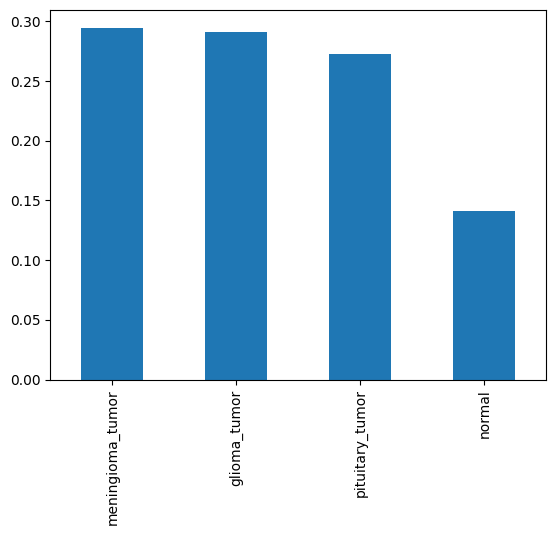

In [95]:
function = lambda file: file.split(os.sep)[2]
iterable = ds_train.file_paths
generator = map(function, iterable)

data = list(generator)  
normalize = True  
sort = True  
kind = "bar"  
frecuencias = pd.Series(data).value_counts(normalize, sort)
#print(frecuencias)
weights = {}
cont = 0
total = 0
for clase,frec in frecuencias.items():
    valor = 1/frec
    weights[clase]= valor
    total += valor
    cont+=1
#print(weights)
#normalizamos pesos
class_weights = {}
cont = 0
for clase,w in weights.items():
    print(clase)
    class_weights[clase] = w/total
    cont+=1
class_indices = {clase: idx for idx, clase in enumerate(frecuencias.keys())}
mapped_class_weights = {class_indices[clase]: peso for clase, peso in class_weights.items()}
print("Pesos para cada clase:")
print("------------------------------------")
print(class_weights)
print("------------------------------------")
print("Frecuencia de aparición de cada clase:")
pd.Series(data).value_counts(normalize, sort).plot(kind = kind);

## 2. Aumentación de datos

Como se definió en el Hito anterior, es necesario introducir aumentación de datos debido a que disponemos de un conjunto de datos reducido. Asimismo, esto proporciona otra medida contra el sobreajuste, ya que, a más datos, más difícil es que el modelo sobreajuste.

In [96]:
from keras import Sequential
from keras import layers
import matplotlib.pyplot as plt
import numpy as np
data_augmentation = Sequential(
    [
        layers.RandomRotation(
        0.1, 
        fill_mode='constant', 
        fill_value=0.0       
        ),
        layers.RandomZoom(
            0.2, 
            fill_mode='constant', # esto hace que las zonas no ampliadas de la imagen se rellenen de color negro
            fill_value=0.0
        )
    ]
)

## 3. Modelos

Los modelos seleccionados para realizar la clasificación del conjunto de datos son redes neuronales convolucionales. Esto se debe a varias razones:
- **Reconocimiento de patrones**: las CNN descifran las características de la imagen, como bordes o texturas, independientemente de dónde se encuentren esos patrones dentro de la imagen. Esto lo logran mediante los filtros de convolución. Esta propiedad de las CNN es vital en nuestro problema, pues commo se pudo ver en el Hito 2, las imágenes se componen de texturas, bordes y contrastes característicos para cada imagen.
- **Reconocimiento incremental**: cuantas más capas de convolución se utilicen, la red será capaz de reconocer patrones y formas más complejos.

En este apartado se definen varios modelos  para observar cómo se comportan 2 redes neuronales de 2 familias distintas: una red neuronal convolucional hecha a mano y una red neuronal pre-entrenada (Transfer Learning).

### 3.1 CNN custom 

In [97]:
import tensorflow as tf
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss"),
        tf.keras.callbacks.CSVLogger("training_log_cnn_custom.csv", append=True)
]

In [98]:
length = 79
model = Sequential([
    layers.Input(shape=(256, 256, 3)),
    data_augmentation, #aplicamos la aumentación de datos
    layers.Rescaling(1./255),
    layers.Conv2D(filters=32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=128, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=256, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=256, kernel_size=3, activation="relu"),
    layers.Flatten(),
    layers.Dropout(0.5), #aplicamos dropout
    layers.Dense(4, activation="softmax")
])
model.summary(length)

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                     ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_14 (Sequential)       │ (None, 256, 256, 3)      │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)          │ (None, 256, 256, 3)      │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)               │ (None, 254, 254, 32)     │           896 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D)  │ (None, 127, 127, 32)     │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)               │ (None, 125, 125, 64)     │        18,496 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D)  │ (None, 62, 62, 64)       │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)               │ (None, 60, 60, 128)      │        73,856 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D)  │ (None, 30, 30, 128)      │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)               │ (None, 28, 28, 256)      │       295,168 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D)  │ (None, 14, 14, 256)      │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)               │ (None, 12, 12, 256)      │       590,080 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ flatten_7 (Flatten)              │ (None, 36864)            │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_7 (Dropout)              │ (None, 36864)            │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_7 (Dense)                  │ (None, 4)                │       147,460 │
└──────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 1,125,956 (4.30 MB)

 Trainable params: 1,125,956 (4.30 MB)

 Non-trainable params: 0 (0.00 B)

In [99]:
import matplotlib.pyplot as plt

def plot_history_from_csv(csv_path):
    if not os.path.exists(csv_path):
        print("No hay historial guardado todavía.")
        return

    df = pd.read_csv(csv_path)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Gráfica de Accuracy
    df[['accuracy', 'val_accuracy']].plot(ax=ax1, marker='o')
    ax1.set_title('Precisión del Modelo')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Época')
    ax1.grid(True)

    # Gráfica de Loss
    df[['loss', 'val_loss']].plot(ax=ax2, marker='o')
    ax2.set_title('Pérdida del Modelo')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Época')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [100]:
lr = 0.001
optimizer = tf.keras.optimizers.Adam(lr)

model.compile(optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [ ]:
from tensorflow.keras.models import load_model
ruta = "./convnet.keras"
if os.path.exists(ruta):
    print("El modelo entrenado ya existe. Modelo cargado")
    model.load_weights(ruta)
    for x, y in ds_test.take(1):
        _ = model.predict(x, verbose=0)
    if os.path.exists('training_history.csv'):
        history_data = pd.read_csv('training_history.csv')
        class DummyHistory:
            def __init__(self, data):
                self.history = data.to_dict(orient='list')
        
        saved_history = DummyHistory(history_data)
        plot_history_from_csv(saved_history)
else:
    history = model.fit(
        x = ds_train,
        epochs=100,
        validation_data= ds_validation,
        callbacks=callbacks,
        class_weight=mapped_class_weights)
    model.save("convnet.keras")
    hist_df = pd.DataFrame(history.history) 
    hist_df.to_csv('training_history_cnn_custom.csv', index=False)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 420ms/step - accuracy: 0.2722 - loss: 0.3317 - val_accuracy: 0.2723 - val_loss: 1.3884
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 413ms/step - accuracy: 0.3229 - loss: 0.3016 - val_accuracy: 0.3404 - val_loss: 1.8687
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.4765 - loss: 0.2622 - val_accuracy: 0.4700 - val_loss: 1.3502
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.5725 - loss: 0.2270 - val_accuracy: 0.5575 - val_loss: 1.0566
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.6049 - loss: 0.2003 - val_accuracy: 0.7066 - val_loss: 0.7430
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 39s 647ms/step - accuracy: 0.6000 - loss: 0.2141 - val_accuracy: 0.6110 - val_loss: 1.1271
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 420ms/step - accuracy: 0.6226 - loss: 0.2080 - val_accuracy: 0.6013 - val_loss: 0.9355
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 441ms/step - accuracy: 0.6631 - loss: 0.1774 - val_accu

In [ ]:
class_names = ds_train.class_names
def predict_and_show_top_3(img_path):
    img = keras.utils.load_img(img_path, target_size=(256, 256))
    img_array = keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Crear batch de 1

    preds = model.predict(img_array)[0]
    top_3_indices = np.argsort(preds)[-3:][::-1]

    print(f"\nResultados para: {os.path.basename(img_path)}")
    for i in top_3_indices:
        print(f"  - {class_names[i]}: {preds[i]*100:.2f}%")
    
    return img_array

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = np.concatenate([y for x, y in ds_test], axis=0)
y_pred_probs = model.predict(ds_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.94      0.83      0.88       181
meningioma_tumor       0.80      0.90      0.85       184
          normal       0.89      0.76      0.82        89
 pituitary_tumor       0.91      0.98      0.94       170

        accuracy                           0.88       624
       macro avg       0.89      0.87      0.87       624
    weighted avg       0.88      0.88      0.88       624



In [ ]:
import matplotlib.cm as cm
from keras import models
def get_gradcam_heatmap(img_array, model, last_conv_layer_name):
    last_conv_layer = model.get_layer(last_conv_layer_name)
    img_input = keras.Input(shape=(256, 256, 3))
    x = img_input
    target_layer_output = None
    curr_x = img_input
    for layer in model.layers:
        curr_x = layer(curr_x)
        if layer.name == last_conv_layer_name:
            target_layer_output = curr_x
            
    grad_model = keras.models.Model(inputs=img_input, outputs=[target_layer_output, curr_x])
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

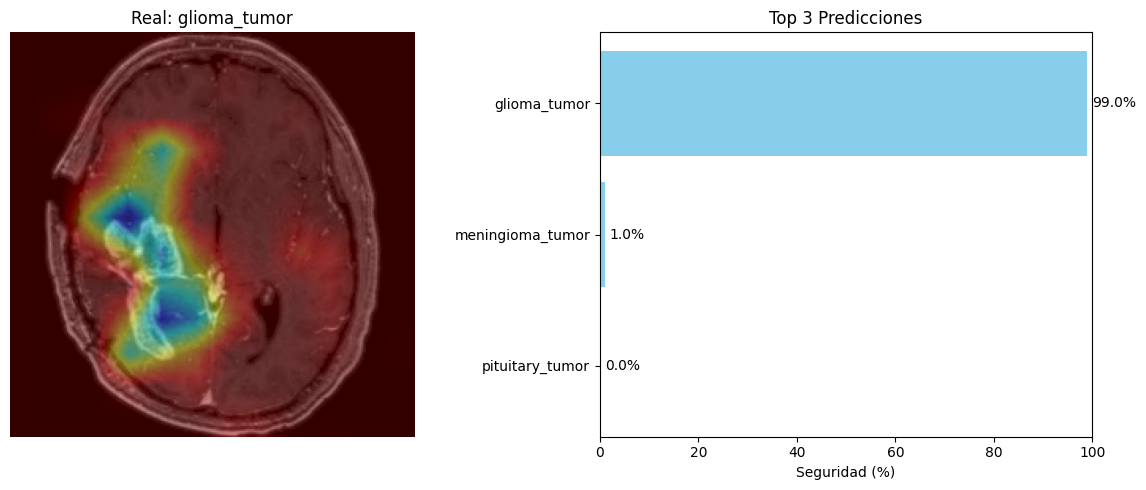

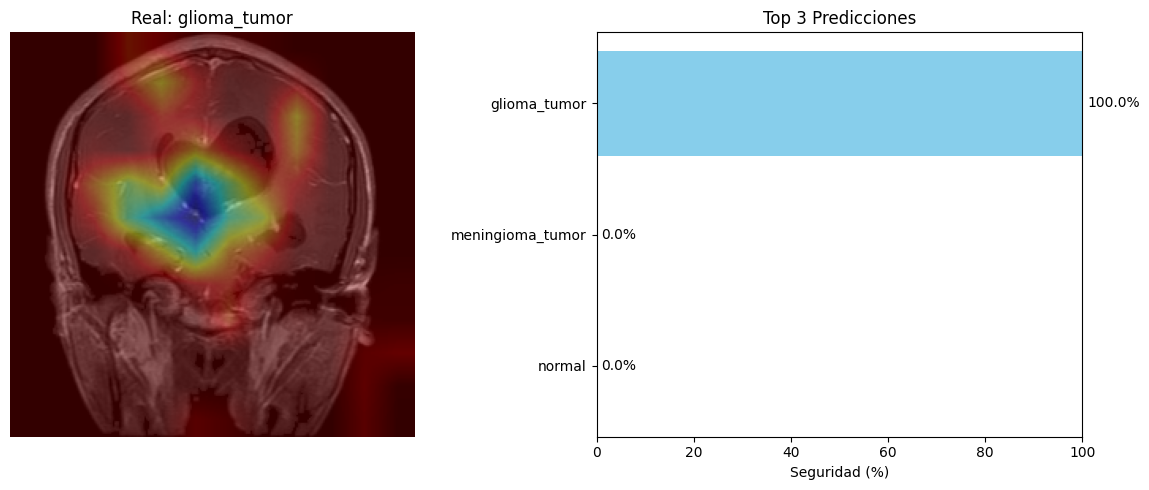

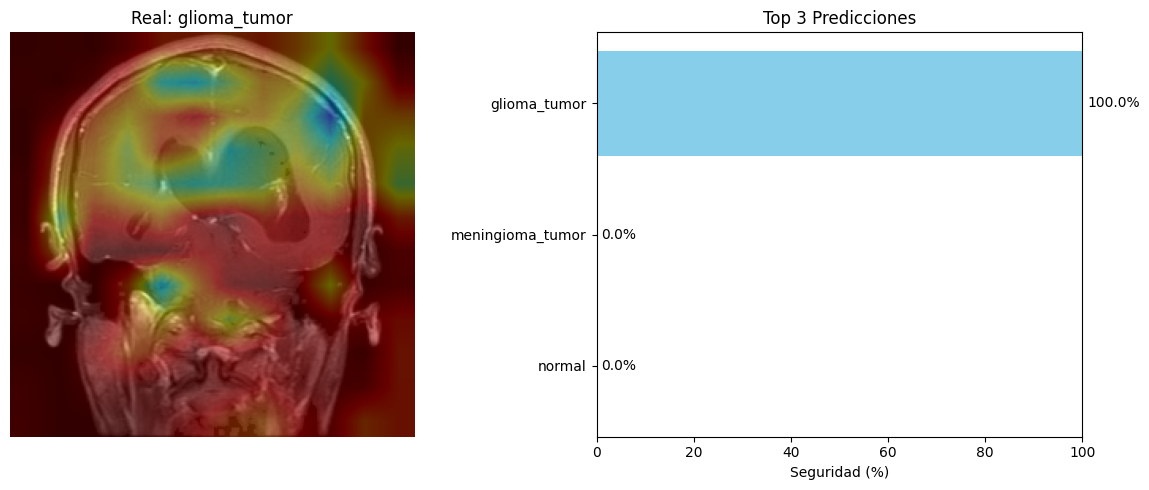

In [ ]:
import matplotlib.pyplot as plt
import cv2

def display_gradcam_results(dataset, model, last_conv_layer_name, num_images=5):
    for i, (img, label) in enumerate(dataset.unbatch().take(num_images)):
        img_tensor = np.expand_dims(img, axis=0)
        preds = model.predict(img_tensor, verbose=0)[0]
        top_3_idx = np.argsort(preds)[-3:][::-1]
        heatmap = get_gradcam_heatmap(img_tensor, model, last_conv_layer_name)
        img_np = img.numpy().astype("uint8")
        heatmap_resized = cv2.resize(heatmap, (256, 256))
    
        heatmap_color = np.uint8(255 * heatmap_resized)
        heatmap_color = cv2.applyColorMap(heatmap_color, cv2.COLORMAP_JET)
        superimposed_img = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)
        
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(superimposed_img)
        plt.title(f"Real: {class_names[label.numpy()]}")
        plt.axis('off')
        plt.subplot(1, 2, 2)
        top_names = [class_names[idx] for idx in top_3_idx]
        top_scores = [preds[idx] * 100 for idx in top_3_idx]
        bars = plt.barh(top_names, top_scores, color='skyblue')
        plt.xlabel('Seguridad (%)')
        plt.title('Top 3 Predicciones')
        plt.xlim(0, 100)
        plt.gca().invert_yaxis()
        
        for bar in bars:
            plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                     f'{bar.get_width():.1f}%', va='center')

        plt.tight_layout()
        plt.show()

display_gradcam_results(ds_test, model, "conv2d_33", num_images=3)

### 3.2 CNN con Transfer Learning

Esta técnica se suele utilizar cuando no se tienen los suficientes recursos para entrenar un modelo desde 0. Se hace uso de un modelo pre-entrenado que se utilizó para resolver un problema similar, y se descongelan algunas capas para adaptarlas al nuevo problema. Hemos elegido **EfficientNetV2M** como función de transfer learning, debido a que se especializa en la clasificación de imágenes, y según las pruebas realizadas en ImageNet, tiene en **Top1 un 85.3% de accuracy**, que es de los más altos dentro de la categoría de EfficientNet.
- **Técnica para combatir el sobreajuste:** Haremos uso de **Dropout**, la cual ha sido explicada anteriormente.
- **Técnica para que el modelo se adapte mejor al problema en cuestión:** Hemos descongelado la primera capa para que el modelo se adapte mejor al problema que estamos tratando, pues nos permitirá identificar mejor las características más básicas de las imágenes a clasificar.
- **Técnica para prevenir el sobreajuste:** La técnica que hemos utilizado es el aumento de datos utilizando un generador de flujo: **ImageDataGenerator**.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rotation_range = 0.1,
    shear_range=0.2,
    zoom_range=0.2
)

In [ ]:
directory = Path(".") / "data" / "train"
batch_size = 32
target_size = (256, 256)
class_mode = "sparse"


train_generator_transfer = train_datagen.flow_from_directory(
    directory,
    batch_size = batch_size,
    target_size = target_size,
    class_mode = class_mode,
    seed = random_state
)

In [ ]:
include_top = False
weights = "imagenet"
input_shape = (256, 256, 3)

model_transf = tf.keras.applications.EfficientNetV2M(include_top, weights, input_shape = input_shape)

In [ ]:
len(model_transf.layers)

In [ ]:
fine_tuning = 446
for layer in model_transf.layers[:fine_tuning]:
    layer.trainable = False

model_transf.layers[0].trainable = True # Descongelamos la primera capa

In [ ]:
x = model_transf.output
x = keras.layers.Flatten("channels_last")(x)
x = keras.layers.Dropout(0.5)(x)
units = 128
activation = "relu"
x = keras.layers.Dense(units, activation)(x)
x = keras.layers.Dense(units, activation)(x)

units = len(class_names)
activation = "softmax"
x = keras.layers.Dense(units, activation)(x)

In [ ]:
inputs = model_transf.input
outputs = x

length = 79

model_transf = keras.Model(inputs, outputs)
model_transf.summary(length)

In [ ]:
lr = 0.001
loss = "sparse_categorical_crossentropy"

optimizer = tf.keras.optimizers.Adam(lr)
metrics = ["accuracy"]

model_transf.compile(optimizer, loss, metrics = metrics)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="transf_model.keras",
        save_best_only=True,
        monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True),
        tf.keras.callbacks.CSVLogger("training_log_tf.csv", append=True)
]

In [ ]:
history = model_transf.fit(
    x = train_generator_transfer,
    validation_data = ds_validation,
    callbacks=callbacks,
    epochs = 50,
    class_weight=mapped_class_weights)

model_transf.save("transf_model.keras")

In [ ]:
y_true = np.concatenate([y for x, y in ds_test], axis=0)
y_pred_probs = model.predict(ds_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
display_gradcam_results(ds_test, model, "conv2d_33", num_images=3)